# Random Sample + Collate + Spectrogram
This cell pair picks a random local LibriSpeech sample, applies `collate_fn`, and visualizes the resulting mel spectrogram.

Transcript: I HAD SCARCELY KNOWN WHAT I HAD BEEN SAYING OR DOING UP TO THIS TIME BUT AS HE SPOKE I LOOKED AT MY HAND
------------------------------------------------------------
Original length (waveform samples): 117200
Original length (seconds): 7.33s
Length now (spectrogram frames in tensor): 733
Length now (input_lengths from collate_fn): 733
Target length (tokens): 104


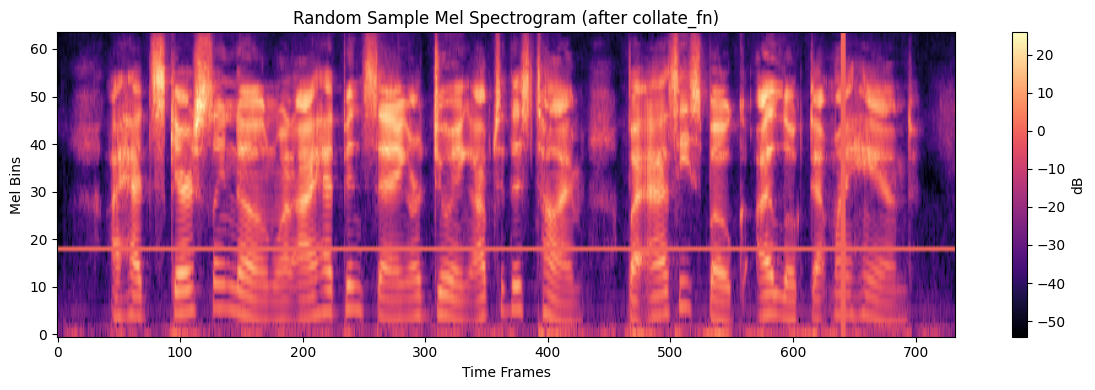

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchaudio
from torch.utils.data import DataLoader, Subset

from model.helpers import collate_fn_test

# Same dataset setup style as train.py
root = "C:/Users/nikan/Desktop/coding/Notarius/datasets"
train_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="test-clean", download=False)
val_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="test-clean", download=False)
test_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="test-clean", download=False)

small_train_ds = Subset(train_ds, range(200))
small_val_ds = Subset(val_ds, range(50))
small_test_ds = Subset(test_ds, range(50))

# Apply collate function through DataLoader
train_loader = DataLoader(
    small_train_ds,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn_test,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

# Get one collated batch (this is your "df" / batch object)
df = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

print(f"Train subset size: {len(small_train_ds)}")
print(f"Batch spectrogram shape: {tuple(spectrogram_batch.shape)}")
print(f"Batch targets shape: {tuple(targets_batch.shape)}")
print(f"Input lengths (first 5): {input_lengths[:5].tolist()}")
print(f"Target lengths (first 5): {target_lengths[:5].tolist()}")

# Show spectrogram of one random item from the collated batch
idx = torch.randint(0, spectrogram_batch.shape[0], (1,)).item()
spec = spectrogram_batch[idx].detach().cpu().numpy()  # (n_mels, time)

plt.figure(figsize=(12, 4))
plt.imshow(spec, aspect="auto", origin="lower", cmap="magma")
plt.title(f"Collated Batch Spectrogram (sample index={idx})")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()